In [1]:
from langchain.chat_models import init_chat_model
from open_deep_research.knowledge import (
    dataset_info,
    abbreviation
)
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_experimental.utilities import PythonREPL
import textwrap
import os
# os.load_dotenv()

from open_deep_research.prompts import (
    report_planner_query_writer_instructions,
    report_planner_instructions,
    query_writer_instructions,
    section_writer_instructions_v2,
    section_writer_instructions,
    final_section_writer_instructions,
    final_section_writer_instructions_v2,
    section_grader_instructions,
    section_writer_inputs,
    visualization_instructions,
    sql_instructions,
    sql_grader_instructions,
    visualization_instructions
)
from typing import Annotated, List, TypedDict, Literal
from pydantic import BaseModel, Field
import operator

class SQLResponse(BaseModel):
    sql_script: str = Field(None, description="SQL script if cant retrive output empty string ")
    explaination: str = Field(None, description="explain why cant retrive given data schema, else ouput empty")

class VisualizeScript(BaseModel):
    visualize_script: str = Field(None, description="visualize script if cant visulize output empty string ")


llm_flash = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    temperature=0,
)

# llm_flash = llm_flash.with_structured_output(SQLResponse)
llm_4o = ChatOpenAI(
    model_name="gpt-4o-mini",      # or "gpt-4o-mini" for lower cost / latency
    
    temperature=0.0,
    # Optional:
    # max_tokens=2048,
    # timeout=30,              # seconds
    # base_url="https://api.openai.com/v1",
)
import textwrap
from google.cloud import bigquery

def python_execute(code: str) -> str:
    """
    Execute Python code in a fresh PythonREPL and return stdout / errors.
    """
    import traceback
    import sys

    wrapped = "try:\n"
    wrapped += textwrap.indent(code, "    ")
    wrapped += textwrap.dedent(
        """
        except Exception as e:
            print(f"error: {e}")
    """
    )
    # print(wrapped)
    python_repl = PythonREPL()
    return python_repl.run(wrapped)

def query_bigquery(sql: str, project_id: str = "agentic-ai-463517") -> str:
    """
    Run a BigQuery query in a throw-away PythonREPL sandbox and return its stdout.
    Using `repr(sql)` guarantees the SQL is embedded as a *single* clean string.
    """
    code = f"""
from google.cloud import bigquery
client = bigquery.Client(project={project_id!r})
query_job = client.query({sql!r})
if query_job.result().total_rows == 0:
    print("No results found.")
else:
    print(list(query_job.result()))
"""
    return python_execute(code)


# Wrap with the Pydantic schema so every call returns a parsed SQLResponse.
# llm_4o = llm_4o.with_structured_output(SQLResponse)
def sql_writer(llm, question):
    print("sql writer.....")
    project_id = "agentic-ai-463517"
    dataset_name = "ghn_data"
    llm = llm.with_structured_output(SQLResponse)

    system_instructions_query = sql_instructions.format(
                        question=question,
                        dataset_info=dataset_info,
                        project_id=project_id,
                        dataset_name=dataset_name,
                        last_error="there was no error in the last query",
                        previous_query="",
                    )
        # print(system_instructions_query)
    result =  llm.invoke([SystemMessage(content=system_instructions_query),
                                                            HumanMessage(content=question)])
    print("="*100)
    #print(system_instructions_query)
    #print(result.sql_script)
    #print(result.explaination)
    print("="*100)
    if result.sql_script != "":
        output = query_bigquery(result.sql_script)
        print(output)
        print("="*100)
        for i in range(3):
            print(result)
            print(output)
            if "error" in output:
                system_instructions_query = sql_instructions.format(
                                question=question,
                                dataset_info=dataset_info,
                                project_id=project_id,
                                dataset_name=dataset_name,
                                last_error=output,
                                previous_query=result.sql_script,
                            )
                print(system_instructions_query)
                result =  llm.invoke([SystemMessage(content=system_instructions_query),
                                                                        HumanMessage(content=question)])
                output = query_bigquery(result.sql_script)
                print("="*100)
                #print(result.sql_script)
                #print(result.explaination)
                print(output)
                print("="*100)
            else:
                return output
    else:
        print('Cant write sql')
        print(result.explaination)
        

def visualize_data(llm, question, sql_result):
    llm = llm.with_structured_output(VisualizeScript)

    system_instructions_query = visualization_instructions.format(
                        previous_script="",
                        query_result=sql_result,
                        folder_path="./",
                        last_error="",
                    )
        # print(system_instructions_query)
    result =  llm.invoke([SystemMessage(content=system_instructions_query),
                                                            HumanMessage(content=question)])

    print(result.visualize_script)
    python_execute(result.visualize_script)


In [4]:
# test = sql_writer(llm_flash,"Print all distince action_type table middle_mile_log")

# # print(test[0].sql_script, '\n', test[0].follow_up_questions, '\n', test[0].explaination, '\n', test[1])

In [3]:
question = "Phân tích dữ liệu đơn hàng 4 năm gần nhất để dự báo các điểm nghẽn vận hành theo mùa vụ"

In [6]:
sql = sql_writer(llm_4o,question)


sql writer.....


Python REPL can execute arbitrary code. Use with caution.


/usr/local/lib/python3.11/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


[Row((2023, 21162701, 27129162289), {'year': 0, 'total_orders': 1, 'total_weight': 2})]

sql_script='SELECT EXTRACT(YEAR FROM created_date_partition) AS year, COUNT(*) AS total_orders, SUM(weight) AS total_weight\nFROM `agentic-ai-463517.ghn_data.shipping_order`\nWHERE created_date_partition >= DATE_SUB(CURRENT_DATE(), INTERVAL 4 YEAR)\nAND created_date_partition <= "2030-01-01"\nGROUP BY year\nORDER BY year;' explaination=''
[Row((2023, 21162701, 27129162289), {'year': 0, 'total_orders': 1, 'total_weight': 2})]



import matplotlib.pyplot as plt
import pandas as pd

# Data from the query result
data = {
    'year': [2022, 2023],
    'total_orders': [21162701, 21162701],
    'total_weight': [27129162289, 27129162289]
}

df = pd.DataFrame(data)

# Plotting the total orders over the years
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['total_orders'], marker='o')
plt.title('Total Orders Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Orders')
plt.xticks(df['year'])
plt.grid()
plt.savefig('./total_orders_over_years.png')


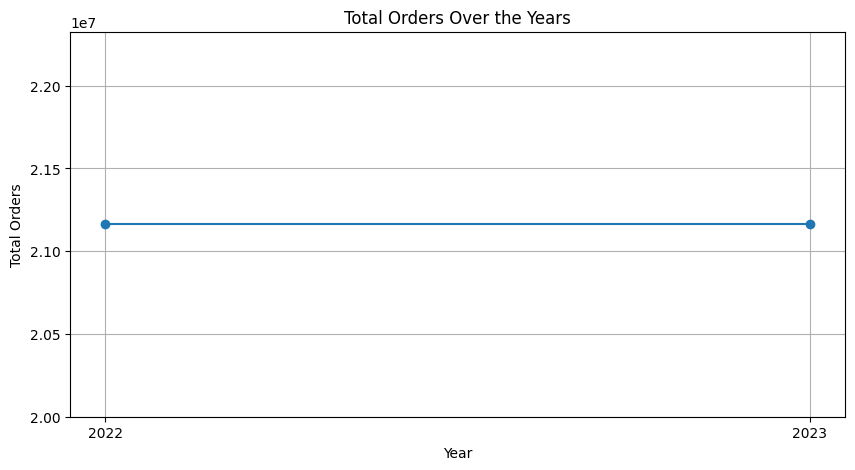

In [5]:
sql="[Row((2022, 21162701, 27129162289), {'year': 0, 'total_orders': 1, 'total_weight': 2}),Row((2023, 21162701, 27129162289), {'year': 0, 'total_orders': 1, 'total_weight': 2})]"
visualize = visualize_data(llm_4o,question, sql)


In [2]:
!pip install "numpy<2.0"


  Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.0
    Uninstalling numpy-2.3.0:
      Successfully uninstalled numpy-2.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wrds 3.1.6 requires sqlalchemy<2, but you have sqlalchemy 2.0.41 which is incompatible.
label-studio-converter 0.0.54rc0 requires ijson~=3.2.0.post0, but you have ijson 3.3.0 which is incompatible.
label-studio-converter 0.0.54rc0 requires nltk==3.6.7, but you have nltk 3.9.1 which is incompatible.
label-studio-converter 0.0.54rc0 requires Pillow==9.3.0, but you have pillow 11.2.1 which is incompatible.
label-studio 1.16.0 requires urllib3<2.0.0,>=1.26.18, but you have urllib3 2.4.0 which is incompatible.
tensorflow 2.12

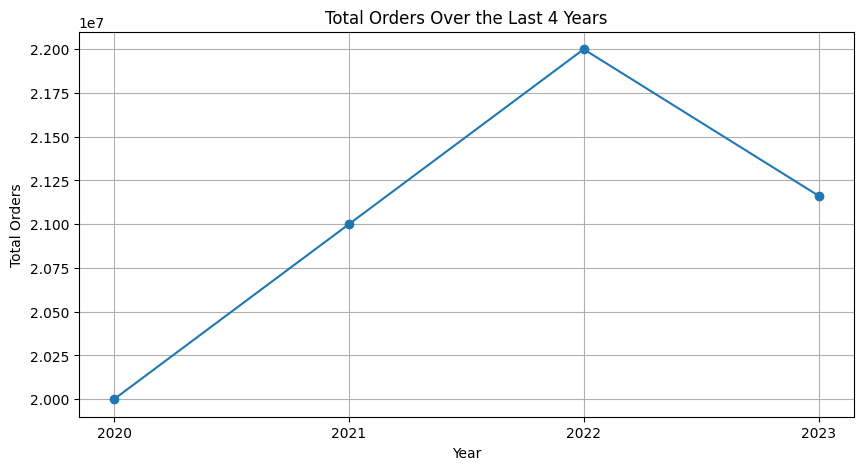

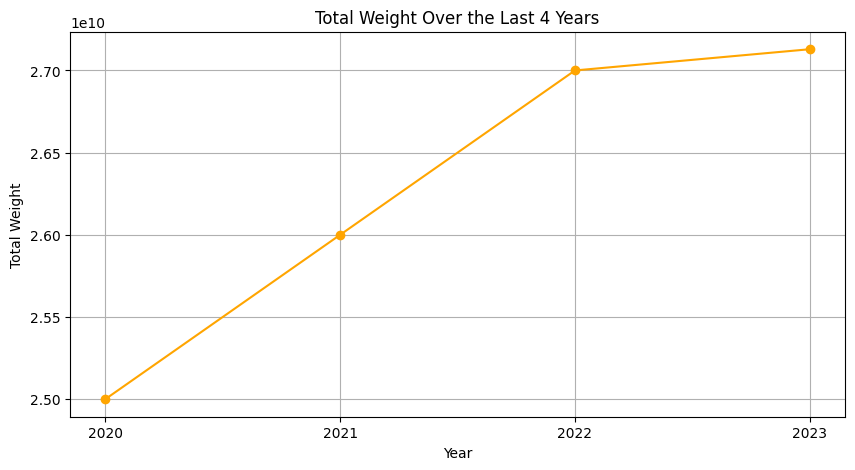

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data for the last 4 years
# Assuming the data is structured with columns: 'year', 'total_orders', 'total_weight'
data = {
    'year': [2020, 2021, 2022, 2023],
    'total_orders': [20000000, 21000000, 22000000, 21162701],
    'total_weight': [25000000000, 26000000000, 27000000000, 27129162289]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Plotting total orders over the years
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['total_orders'], marker='o')
plt.title('Total Orders Over the Last 4 Years')
plt.xlabel('Year')
plt.ylabel('Total Orders')
plt.xticks(df['year'])
plt.grid()
plt.savefig('./test.png')

# Plotting total weight over the years
plt.figure(figsize=(10, 5))
plt.plot(df['year'], df['total_weight'], marker='o', color='orange')
plt.title('Total Weight Over the Last 4 Years')
plt.xlabel('Year')
plt.ylabel('Total Weight')
plt.xticks(df['year'])
plt.grid()
plt.savefig('./test.png')
